In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
data= pd.read_csv("heart.csv")

In [4]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [5]:
data["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [6]:
x= data.iloc[:,:-1].copy()
y= data.iloc[:,-1].copy()

In [7]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2


In [8]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 104.2 KB


In [9]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
x_train.shape

(820, 13)

In [11]:
from tensorflow import keras

In [12]:
from keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.regularizers import L2

In [13]:
model= Sequential([
    Input(shape=(13,)),
    # Dropout(0.3),
    Dense(8, activation="relu", kernel_initializer="he_normal"),
    # Dropout(0.2),
    # BatchNormalization(),
    Dense(4, activation="relu", kernel_initializer="he_normal"),
    Dropout(0.4),
    # BatchNormalization(),
    Dense(2, activation="relu", kernel_initializer="he_normal"),
    # BatchNormalization(),
    Dense(1, activation="sigmoid")
])

In [14]:
model.compile(
    optimizer="Adam",
    loss= "binary_crossentropy",
    metrics= ["accuracy"]
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
scaler= StandardScaler()

In [17]:
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [18]:
callback= EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    mode= "auto",
    baseline=None,
    restore_best_weights=True,
    verbose=1
)

In [19]:
history= model.fit(x_train_scaled, y_train, epochs=150, batch_size=16, validation_split=0.2, callbacks=callback, verbose=1)

Epoch 1/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5671 - loss: 0.6813 - val_accuracy: 0.4939 - val_loss: 0.6916
Epoch 2/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5854 - loss: 0.6788 - val_accuracy: 0.5610 - val_loss: 0.6791
Epoch 3/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6326 - loss: 0.6618 - val_accuracy: 0.5671 - val_loss: 0.6665
Epoch 4/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6631 - loss: 0.6328 - val_accuracy: 0.6037 - val_loss: 0.6494
Epoch 5/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6738 - loss: 0.6118 - val_accuracy: 0.6341 - val_loss: 0.6266
Epoch 6/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6585 - loss: 0.5839 - val_accuracy: 0.6890 - val_loss: 0.6032
Epoch 7/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7226 - loss: 0.5424 - val_accuracy: 0.7012 - val_loss: 0.5771
Epoch 8/150
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7378 - loss: 0.5144 - val_accuracy: 0.7073 - v

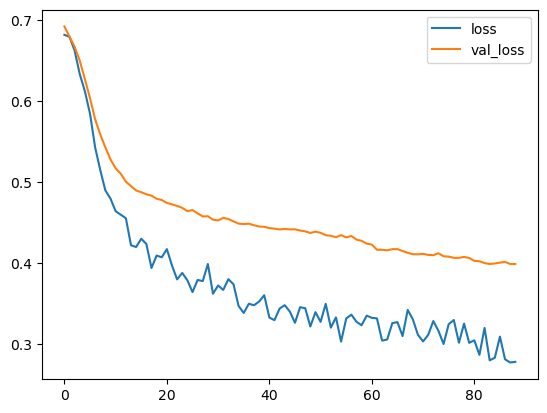

In [20]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()

In [21]:
y_pred_prob= model.predict(x_test_scaled)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [22]:
y_pred_prob= y_pred_prob.ravel()

In [23]:
y_pred_prob.shape

(205,)

In [24]:
def final_result(y_pred_prob):
    for i in range(len(y_pred_prob)):
        if y_pred_prob[i]>=0.5:
            y_pred_prob[i]= 1
        else:
            y_pred_prob[i]= 0
    return y_pred_prob

In [25]:
y_pred= final_result(y_pred_prob)

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
accuracy_score(y_test, y_pred)

0.824390243902439